# LeNet CNN

In [1]:
%matplotlib inline

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
batch_size = 50

## Reading Data

We are reading MNIST data from http://yann.lecun.com/exdb/mnist/


In [10]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

x_train, x_test = x_train / 255., x_test / 255.

train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(1).batch(batch_size).prefetch(1)

In [11]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


## Defining model using conv2d, RELU and Maxpooling

In [12]:
model = keras.Sequential()

model.add(keras.layers.Conv2D(filters=6, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(keras.layers.MaxPooling2D())

model.add(keras.layers.Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D())

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(units=120, activation='relu'))

model.add(keras.layers.Dense(units=84, activation='relu'))

model.add(keras.layers.Dense(units=10, activation = 'softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 6)         60        
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 6)         0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 11, 11, 16)        880       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 5, 5, 16)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 400)               0         
                                                                 
 dense_3 (Dense)             (None, 120)              

## Train model

In [13]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer = 'sgd',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.7044 - accuracy: 0.7792 - val_loss: 0.2004 - val_accuracy: 0.9395
Epoch 2/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.1724 - accuracy: 0.9480 - val_loss: 0.1124 - val_accuracy: 0.9650
Epoch 3/10
1875/1875 [==============================] - 22s 12ms/step - loss: 0.1179 - accuracy: 0.9635 - val_loss: 0.1054 - val_accuracy: 0.9663
Epoch 4/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0940 - accuracy: 0.9706 - val_loss: 0.0795 - val_accuracy: 0.9738
Epoch 5/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0795 - accuracy: 0.9751 - val_loss: 0.0729 - val_accuracy: 0.9762
Epoch 6/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.0677 - accuracy: 0.9790 - val_loss: 0.0606 - val_accuracy: 0.9805
Epoch 7/10
1875/1875 [==============================] - 31s 17ms/step - loss: 0.0605 - accuracy: 0.9814 - val_loss: 0.0564 -

## Visualize the learning process

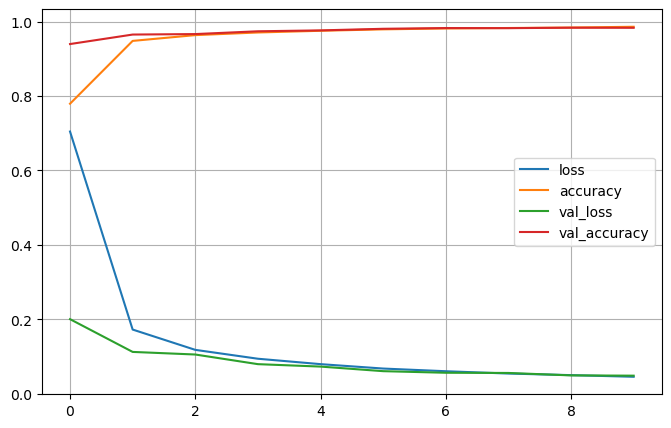

In [14]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca()
plt.show()

## Test with sample images

1/1 [==============================] - 0s 141ms/step
[[3.07014925e-05 9.98031437e-01 8.36046274e-06 1.24594465e-06
  5.60955414e-05 9.63804183e-08 3.41537816e-06 1.82352273e-03
  3.10655269e-05 1.39993381e-05]
 [1.15852106e-10 1.91069969e-08 9.99909639e-01 9.50517096e-06
  1.37459555e-09 1.45588992e-11 1.98571343e-13 8.07041579e-05
  6.75174192e-08 3.47044088e-10]
 [2.00300310e-05 1.21356962e-07 1.55982434e-05 1.41863339e-07
  5.79454718e-06 8.55809152e-01 2.60964828e-03 1.35906680e-06
  1.40975058e-01 5.63086534e-04]
 [1.93359418e-04 3.06068063e-02 2.14056624e-03 9.55965137e-04
  2.87542275e-06 6.42653231e-06 8.25882562e-09 3.42571889e-06
  9.66059446e-01 3.10729338e-05]
 [9.99985695e-01 4.06544736e-08 1.77589982e-06 1.50056056e-08
  6.31849986e-08 5.72785153e-09 1.05341726e-07 7.46761771e-06
  2.07173366e-06 2.66635084e-06]]


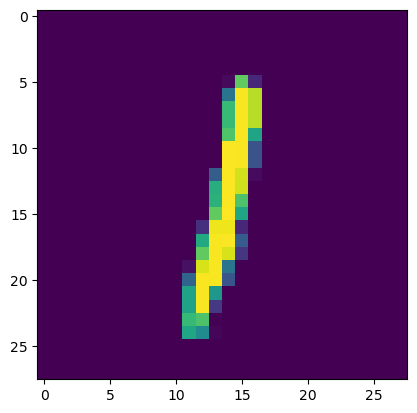

Predicted: 1


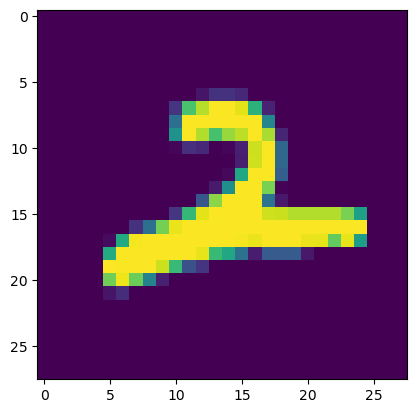

Predicted: 2


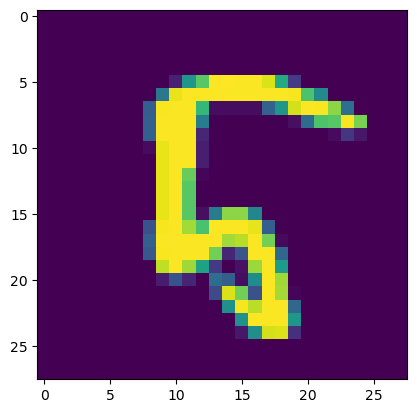

Predicted: 5


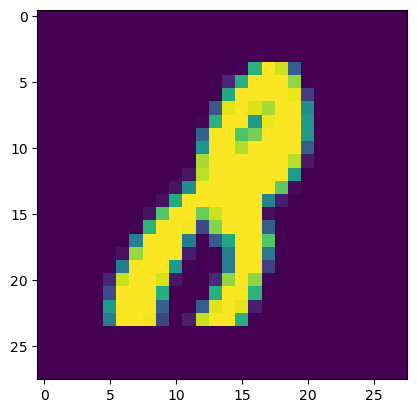

Predicted: 8


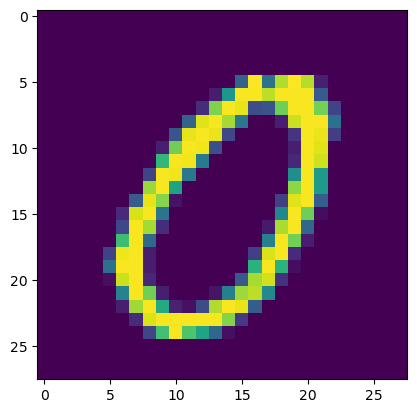

Predicted: 0


In [15]:
test_images = x_test[1030:1035]
pred = model.predict(test_images)
print(pred)
for i in range(pred.shape[0]):
    plt.imshow(np.reshape(test_images[i], [28, 28]))
    plt.show()
    print("Predicted: %i" %np.argmax(pred[i]))